In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

In [14]:
# Remove duplicate flow records to prevent train/test leakage
feat_cols_for_dedup = [c for c in df.columns if c != "Attack_type"]
print("Rows before dedup:", len(df))
df = df.drop_duplicates(subset=feat_cols_for_dedup).reset_index(drop=True)
print("Rows after dedup:", len(df))

Rows before dedup: 123117
Rows after dedup: 18272


In [15]:
df = pd.read_csv("RT_IOT2022.csv")  
cols_to_drop = ["Unnamed: 0", "Flow_ID", "Source_IP", "Destination_IP", "Timestamp", "id.orig_p", "id.resp_p"]
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True)

df.head()

,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,tcp,-,0.000001,1,1,0,0,838860.8,838860.8,1677721.6,...,0.0,0.0,0.0,0.0,0.0,0.0,1024,0,1024,NMAP_OS_DETECTION
1,tcp,-,0.000001,1,1,1,0,1048576.0,1048576.0,2097152.0,...,0.0,0.0,0.0,0.0,0.0,0.0,64,0,64,DOS_SYN_Hping
2,tcp,-,0.000001,1,1,1,0,1048576.0,1048576.0,2097152.0,...,0.0,0.0,0.0,0.0,0.0,0.0,64,0,64,DOS_SYN_Hping
3,tcp,-,0.000001,1,1,1,0,1048576.0,1048576.0,2097152.0,...,0.0,0.0,0.0,0.0,0.0,0.0,64,0,64,DOS_SYN_Hping
4,tcp,-,0.000000,1,0,1,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,64,0,64,DOS_SYN_Hping


In [16]:
normal_traffic = ["Thing_Speak", "Wipro_bulb", "MQTT_Publish"]

df["Attack_type"] = df["Attack_type"].apply(lambda x: 0 if x in normal_traffic else 1)

print("\nClass Distribution after Binary Conversion:")
print(df["Attack_type"].value_counts(normalize=True) * 100) # Shows percentage


Class Distribution after Binary Conversion:
Attack_type
1    89.36
0    10.64
Name: proportion, dtype: float64


In [17]:
label_encoders = {}
for col in df.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

X = df.drop(columns=["Attack_type"])
y = df["Attack_type"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
train_df_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
train_df_scaled['Target'] = y_train.values

normal_train = train_df_scaled[train_df_scaled['Target'] == 0]
attack_train = train_df_scaled[train_df_scaled['Target'] == 1]

n_samples = min(len(normal_train), 5000) 
svm_train_data = pd.concat([
    normal_train.sample(n_samples, random_state=42),
    attack_train.sample(n_samples, random_state=42)
]).sample(frac=1, random_state=42) # Shuffle

X_train_svm = svm_train_data.drop(columns=['Target'])
y_train_svm = svm_train_data['Target']

print(f"SVM training subset size: {len(svm_train_data)} rows")

SVM training subset size: 852 rows


In [20]:
print("\nTraining Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced")
rf_model.fit(X_train_scaled, y_train)

# 5-Fold Cross Validation for Random Forest
cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print(f"RF 5-Fold CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

print("\nTraining SVM (on optimized balanced subset)...")
# Probability=True is required to plot the ROC curve later
svm_model = SVC(kernel="rbf", C=1.0, probability=True, random_state=42)
svm_model.fit(X_train_svm, y_train_svm)


Training Random Forest...
RF 5-Fold CV Accuracy: 0.9925 (+/- 0.0027)

Training SVM (on optimized balanced subset)...


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [21]:
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report

# 1. Initialize the individual models
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, eval_metric='logloss')
lgb_model = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=5)

# 2. Train both models
xgb_model.fit(X_train, y_train)
lgb_model.fit(X_train, y_train)

# 3. Hybrid Prediction Logic (Weighted Averaging)
def hybrid_predict(X, w1=0.6, w2=0.4):
    # Get probability scores for the "Attack" class (Class 1)
    prob_xgb = xgb_model.predict_proba(X)[:, 1]
    prob_lgb = lgb_model.predict_proba(X)[:, 1]
    
    # Calculate Weighted Average
    final_probs = (w1 * prob_xgb) + (w2 * prob_lgb)
    
    # Convert probabilities to binary labels (Threshold = 0.5)
    return (final_probs > 0.5).astype(int)

# 4. Evaluate the Hybrid Model
y_pred_hybrid = hybrid_predict(X_test)

print("--- HYBRID MODEL (XGBoost + LightGBM) PERFORMANCE ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_hybrid)}")
print(classification_report(y_test, y_pred_hybrid))

[LightGBM] [Info] Number of positive: 3574, number of negative: 426
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002565 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6962
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 75
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.893500 -> initscore=2.127001
[LightGBM] [Info] Start training from score 2.127001
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

In [22]:
rf_pred = rf_model.predict(X_test_scaled)
svm_pred = svm_model.predict(X_test_scaled) # Test on the FULL test set!

print("\n--- Random Forest Metrics ---")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred, target_names=["Normal", "Attack"]))

print("\n--- SVM Metrics ---")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred, target_names=["Normal", "Attack"]))


--- Random Forest Metrics ---
Accuracy: 0.998
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99       106
      Attack       1.00      1.00      1.00       894

    accuracy                           1.00      1000
   macro avg       1.00      0.99      0.99      1000
weighted avg       1.00      1.00      1.00      1000


--- SVM Metrics ---
Accuracy: 0.951
              precision    recall  f1-score   support

      Normal       0.69      0.97      0.81       106
      Attack       1.00      0.95      0.97       894

    accuracy                           0.95      1000
   macro avg       0.84      0.96      0.89      1000
weighted avg       0.96      0.95      0.95      1000



C:\Users\ADITI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2750: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


C:\Users\ADITI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2750: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


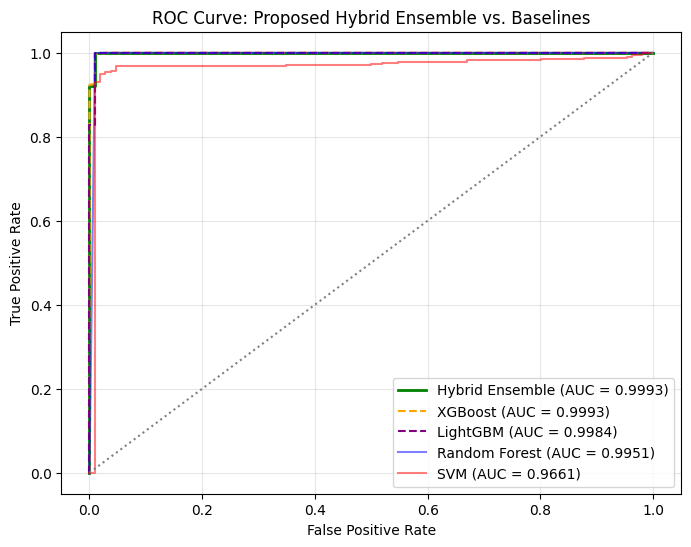

In [23]:
from sklearn.metrics import roc_curve, auc

rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1]
svm_probs = svm_model.predict_proba(X_test_scaled)[:, 1]

prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
prob_lgb = lgb_model.predict_proba(X_test)[:, 1]
hybrid_probs = (0.6 * prob_xgb) + (0.4 * prob_lgb)

xgb_fpr, xgb_tpr, _ = roc_curve(y_test, prob_xgb)
lgb_fpr, lgb_tpr, _ = roc_curve(y_test, prob_lgb)
hyb_fpr, hyb_tpr, _ = roc_curve(y_test, hybrid_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_probs)

xgb_auc = auc(xgb_fpr, xgb_tpr)
lgb_auc = auc(lgb_fpr, lgb_tpr)
hyb_auc = auc(hyb_fpr, hyb_tpr)
rf_auc = auc(rf_fpr, rf_tpr)
svm_auc = auc(svm_fpr, svm_tpr)

plt.figure(figsize=(8,6))
plt.plot(hyb_fpr, hyb_tpr, label=f"Hybrid Ensemble (AUC = {hyb_auc:.4f})", color='green', linewidth=2)
plt.plot(xgb_fpr, xgb_tpr, label=f"XGBoost (AUC = {xgb_auc:.4f})", color='orange', linestyle='--')
plt.plot(lgb_fpr, lgb_tpr, label=f"LightGBM (AUC = {lgb_auc:.4f})", color='purple', linestyle='--')
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.4f})", color='blue', alpha=0.5)
plt.plot(svm_fpr, svm_tpr, label=f"SVM (AUC = {svm_auc:.4f})", color='red', alpha=0.5)
plt.plot([0,1],[0,1], linestyle=":", color='gray')
plt.title("ROC Curve: Proposed Hybrid Ensemble vs. Baselines")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.legend(loc="lower right"); plt.grid(alpha=0.3)
plt.show()

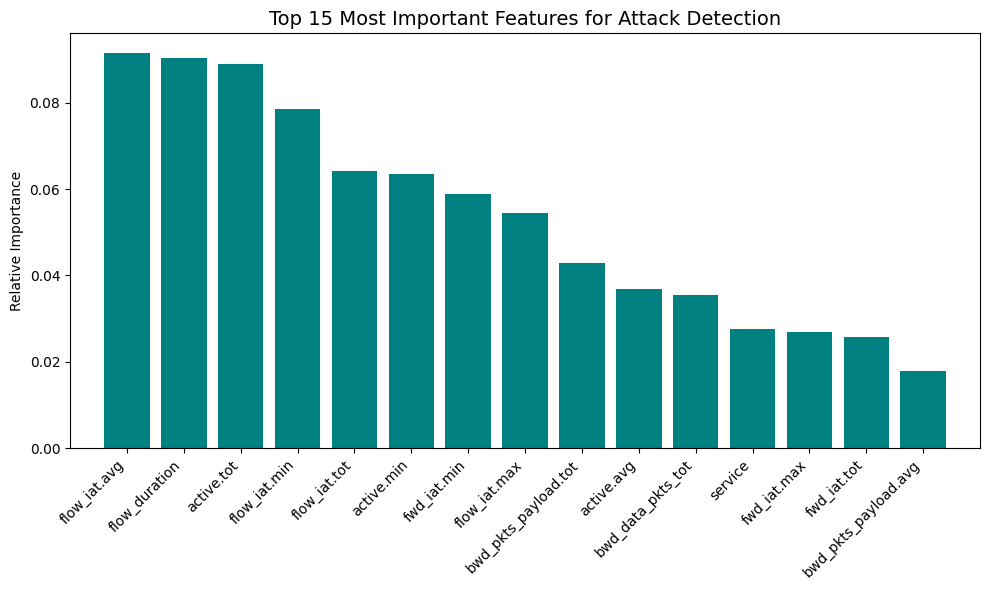

In [24]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

top_n = 15
plt.figure(figsize=(10, 6))
plt.title(f"Top {top_n} Most Important Features for Attack Detection", fontsize=14)
plt.bar(range(top_n), importances[indices[:top_n]], color='teal', align="center")
plt.xticks(range(top_n), X.columns[indices[:top_n]], rotation=45, ha='right')
plt.xlim([-1, top_n])
plt.ylabel("Relative Importance")
plt.tight_layout()
plt.show()

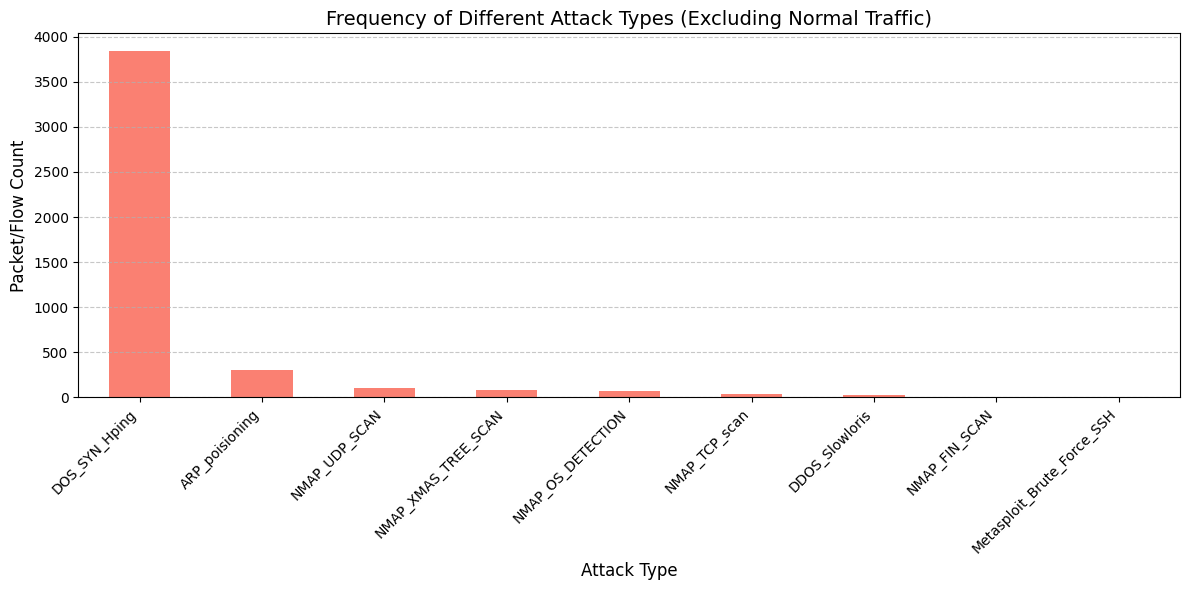

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the raw dataset
df = pd.read_csv("RT_IOT2022.csv")

# 2. Define the normal activities to exclude
normal_activities = ["Thing_Speak", "Wipro_bulb", "MQTT_Publish"]

# 3. Filter for only attack entries
attack_df = df[~df['Attack_type'].isin(normal_activities)]

# 4. Count the occurrences of each unique attack type
attack_counts = attack_df['Attack_type'].value_counts()

# 5. Create the Bar Graph
plt.figure(figsize=(12, 6))
attack_counts.plot(kind='bar', color='salmon')

plt.title("Frequency of Different Attack Types (Excluding Normal Traffic)", fontsize=14)
plt.xlabel("Attack Type", fontsize=12)
plt.ylabel("Packet/Flow Count", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


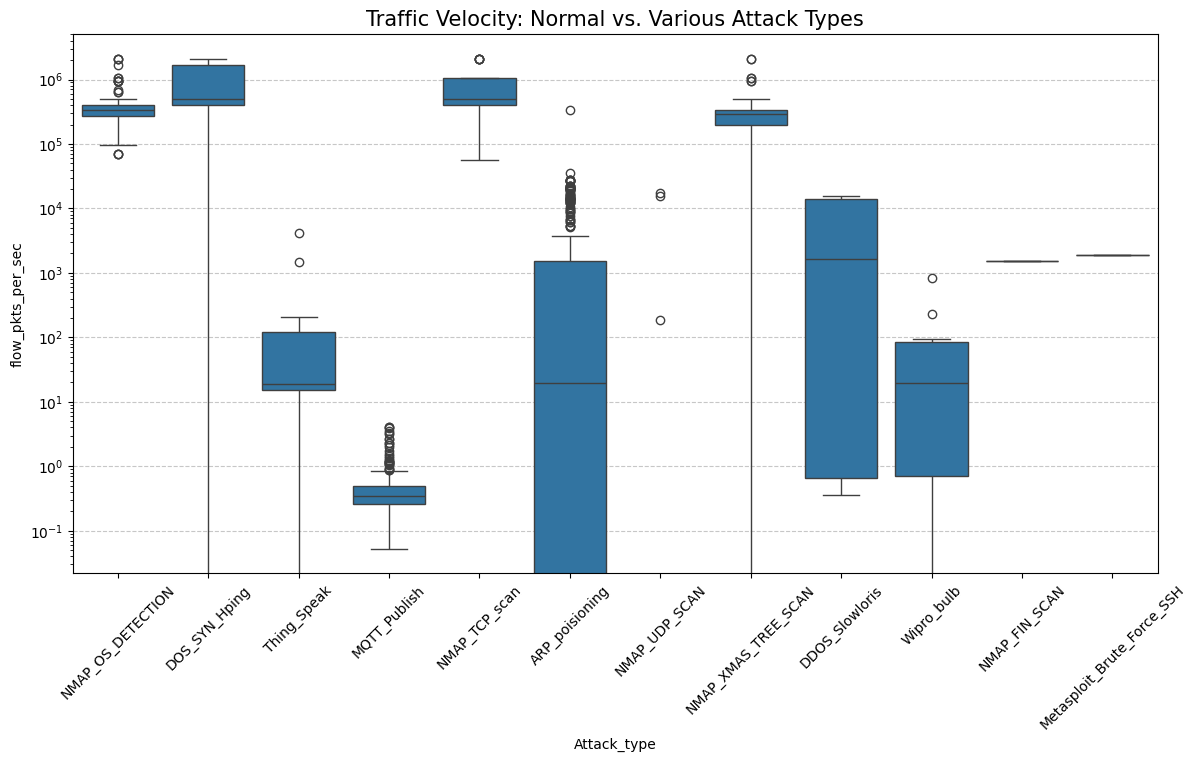

In [27]:

import seaborn as sns
import matplotlib.pyplot as plt
# Comparison of Packet Rate across different activities
plt.figure(figsize=(14, 7))
sns.boxplot(x='Attack_type', y='flow_pkts_per_sec', data=df)
plt.yscale('log') # Attacks often have 1000x higher rates, so log scale is better
plt.title("Traffic Velocity: Normal vs. Various Attack Types", fontsize=15)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

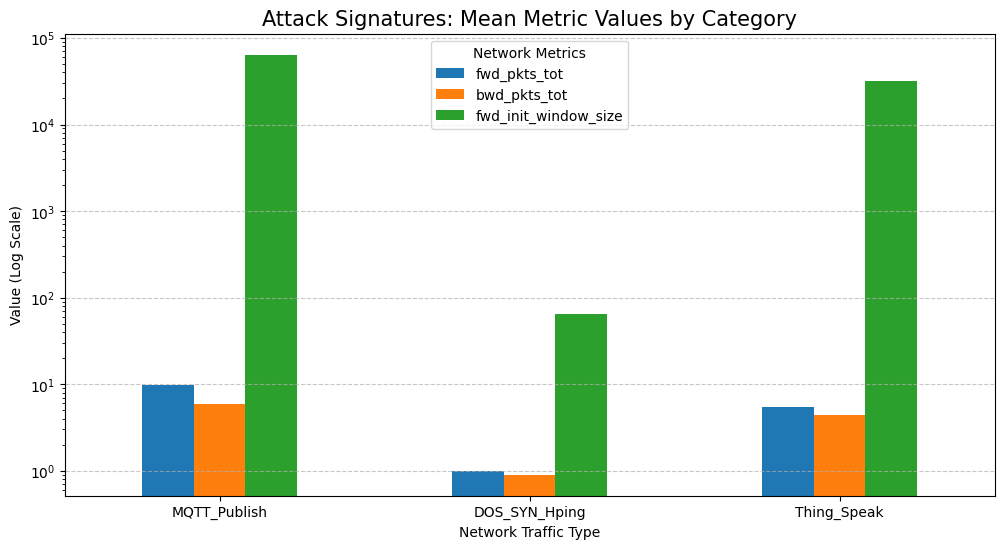

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Re-run this to ensure you have the original string names available
# In a real scenario, you would do this BEFORE the binary conversion
df_plot = pd.read_csv("RT_IOT2022.csv") 

# 2. Select metrics that highlight IoT device behavior
metrics = ['fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_init_window_size']

# 3. Group by the ORIGINAL string names
# We use .loc to pick specific rows for a clear research comparison
comparison_df = df_plot.groupby('Attack_type')[metrics].mean().loc[['MQTT_Publish', 'DOS_SYN_Hping', 'Thing_Speak']]

# 4. Plot the Research Graph
comparison_df.plot(kind='bar', figsize=(12, 6), logy=True)
plt.title("Attack Signatures: Mean Metric Values by Category", fontsize=15)
plt.ylabel("Value (Log Scale)")
plt.xlabel("Network Traffic Type")
plt.xticks(rotation=0)
plt.legend(title="Network Metrics")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [30]:
import pandas as pd
import time
import numpy as np

# ==========================================
# 1. DEFINE THE ENHANCED IDENTIFICATION METHOD
# ==========================================
def detect_and_explain(raw_flow, scaled_flow, model, baseline, actual_label):
    """
    Scans a single network flow from the dataset.
    Identifies if it's an attack (YES/NO) and names the SPECIFIC TYPE.
    """
    start_time = time.time()
    
    # Model predicts 0 or 1 (The binary decision for your mentor)
    prediction = model.predict(scaled_flow)[0]
    scan_time = (time.time() - start_time) * 1000 # Convert to ms
    
    # MENTOR REQUEST: Binary YES/NO status
    status = "YES" if prediction == 1 else "NO"
    
    if status == "YES":
        print(f"\n🚨 ATTACK DETECTED? {status}")
        # Displays the actual name from the dataset (e.g., DDOS_Slowloris)
        print(f"   [!] SPECIFIC TYPE: {actual_label}") 
        print(f"   [!] ANALYSIS SPEED: {scan_time:.2f} ms")
        
        # Explain the 'Why' using irregularities
        print("   [!] TOP IRREGULARITIES CAUSING THIS ALERT:")
        irregularities = []
        for feature in raw_flow.index:
            curr = raw_flow[feature]
            base = baseline[feature]
            # Calculate deviation from normal baseline
            deviation = abs(curr - base) / base if base > 0 else curr
            if deviation > 0.5: 
                irregularities.append((feature, curr, base, deviation))
        
        # Show top 3 reasons why it was flagged
        irregularities.sort(key=lambda x: x[3], reverse=True)
        for feat, curr, base, dev in irregularities[:3]:
            print(f"       🚩 {feat}: {curr:.4f} (Normal baseline is ~{base:.4f})")
            
    else:
        # It's normal traffic
        print(f"\n✅ ATTACK DETECTED? {status}")
        # Displays the normal activity name (e.g., MQTT_Publish)
        print(f"   [+] ACTIVITY TYPE: {actual_label}") 
        print(f"   [+] ANALYSIS SPEED: {scan_time:.2f} ms")
        print("       - Behavior matches normal smart home patterns.")

# ==========================================
# 2. RUN THE SCANNER ON YOUR RESEARCH DATA
# ==========================================

# 1. Load the dataset
df = pd.read_csv('RT_IOT2022.csv')

# 2. Map original labels to binary (0 = Normal, 1 = Attack)
normal_activities = ['MQTT_Publish', 'Thing_Speak', 'Wipro_bulb']
df['Target'] = df['Attack_type'].apply(lambda x: 0 if x in normal_activities else 1)

# 3. Create string labels for the test set using the original index
# Ye line '1.0' ko hata kar asli naam (Attack_type) dikhayegi
y_test_labels = df.loc[X_test.index, 'Attack_type']

# 4. Prepare the test samples with a balanced 50/50 mix
test_samples = X_test.copy()
test_samples['Target'] = y_test
test_samples['Actual_Name_String'] = y_test_labels # Store text labels here

# Mix 5 Normal and 5 Attack for a clear demonstration
random_normal = test_samples[test_samples['Target'] == 0].sample(5) 
random_attack = test_samples[test_samples['Target'] == 1].sample(5)
mixed_traffic = pd.concat([random_normal, random_attack]).sample(frac=1)

# =====================================================================
# FIX: Calculate the normal baseline before running the loop!
# We isolate the normal traffic and find the mean for every feature
# =====================================================================
normal_data = test_samples[test_samples['Target'] == 0].drop(['Target', 'Actual_Name_String'], axis=1)
normal_baseline = normal_data.mean()
# =====================================================================

print("=" * 85)
print("🔍 RESEARCH MODE: BINARY DECISION & ATTACK IDENTIFICATION (RT_IOT2022)")
print("=" * 85)

for i, (idx, row) in enumerate(mixed_traffic.iterrows()):
    # Extract the string name and features
    actual_type_name = row['Actual_Name_String']
    raw_flow = row.drop(['Target', 'Actual_Name_String'])
    scaled_flow = scaler.transform(raw_flow.values.reshape(1, -1))
    
    print(f"\n--- Scanning Packet/Flow #{i + 1} ---")
    
    # Call the method with the text label
    detect_and_explain(raw_flow, scaled_flow, rf_model, normal_baseline, actual_type_name)

print("\n" + "=" * 85)

🔍 RESEARCH MODE: BINARY DECISION & ATTACK IDENTIFICATION (RT_IOT2022)

--- Scanning Packet/Flow #1 ---


C:\Users\ADITI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2750: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



🚨 ATTACK DETECTED? YES
   [!] SPECIFIC TYPE: DOS_SYN_Hping
   [!] ANALYSIS SPEED: 419.89 ms
   [!] TOP IRREGULARITIES CAUSING THIS ALERT:
       🚩 payload_bytes_per_second: 100663296.0000 (Normal baseline is ~2458.8335)
       🚩 bwd_pkts_per_sec: 838860.8000 (Normal baseline is ~21.9000)
       🚩 flow_pkts_per_sec: 1677721.6000 (Normal baseline is ~44.4566)

--- Scanning Packet/Flow #2 ---

✅ ATTACK DETECTED? NO
   [+] ACTIVITY TYPE: Thing_Speak
   [+] ANALYSIS SPEED: 37.82 ms
       - Behavior matches normal smart home patterns.

--- Scanning Packet/Flow #3 ---

✅ ATTACK DETECTED? NO
   [+] ACTIVITY TYPE: MQTT_Publish
   [+] ANALYSIS SPEED: 32.81 ms
       - Behavior matches normal smart home patterns.

--- Scanning Packet/Flow #4 ---

✅ ATTACK DETECTED? NO
   [+] ACTIVITY TYPE: Wipro_bulb
   [+] ANALYSIS SPEED: 32.38 ms
       - Behavior matches normal smart home patterns.

--- Scanning Packet/Flow #5 ---


C:\Users\ADITI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2750: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\ADITI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2750: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\ADITI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2750: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\ADITI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-pac


🚨 ATTACK DETECTED? YES
   [!] SPECIFIC TYPE: DOS_SYN_Hping
   [!] ANALYSIS SPEED: 110.34 ms
   [!] TOP IRREGULARITIES CAUSING THIS ALERT:
       🚩 payload_bytes_per_second: 29606851.7647 (Normal baseline is ~2458.8335)
       🚩 bwd_pkts_per_sec: 246723.7647 (Normal baseline is ~21.9000)
       🚩 flow_pkts_per_sec: 493447.5294 (Normal baseline is ~44.4566)

--- Scanning Packet/Flow #6 ---

✅ ATTACK DETECTED? NO
   [+] ACTIVITY TYPE: MQTT_Publish
   [+] ANALYSIS SPEED: 26.77 ms
       - Behavior matches normal smart home patterns.

--- Scanning Packet/Flow #7 ---

✅ ATTACK DETECTED? NO
   [+] ACTIVITY TYPE: MQTT_Publish
   [+] ANALYSIS SPEED: 58.29 ms
       - Behavior matches normal smart home patterns.

--- Scanning Packet/Flow #8 ---

🚨 ATTACK DETECTED? YES
   [!] SPECIFIC TYPE: DOS_SYN_Hping
   [!] ANALYSIS SPEED: 26.10 ms
   [!] TOP IRREGULARITIES CAUSING THIS ALERT:
       🚩 payload_bytes_per_second: 31457280.0000 (Normal baseline is ~2458.8335)
       🚩 bwd_pkts_per_sec: 262144.0

C:\Users\ADITI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2750: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\ADITI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2750: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\ADITI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2750: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\ADITI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-pac

In [ ]:
import joblib

# These files are MADE AUTOMATICALLY when you run this code
joblib.dump(rf_model, 'model.pkl')          # The trained brain
joblib.dump(scaler, 'scaler.pkl')          # The data formatter
joblib.dump(X_train.columns.tolist(), 'features.pkl') # The list of 77 features
joblib.dump(X_train[y_train == 0].mean(), 'baseline.pkl') # Normal averages

print("✅ 4 files created: model.pkl, scaler.pkl, features.pkl, baseline.pkl")

✅ 4 files created: model.pkl, scaler.pkl, features.pkl, baseline.pkl
